In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('iris (1).csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Feature and their types:")
df.dtypes

Feature and their types:


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df.shape

(150, 5)

In [7]:
df.index

RangeIndex(start=0, stop=150, step=1)

In [8]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [9]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

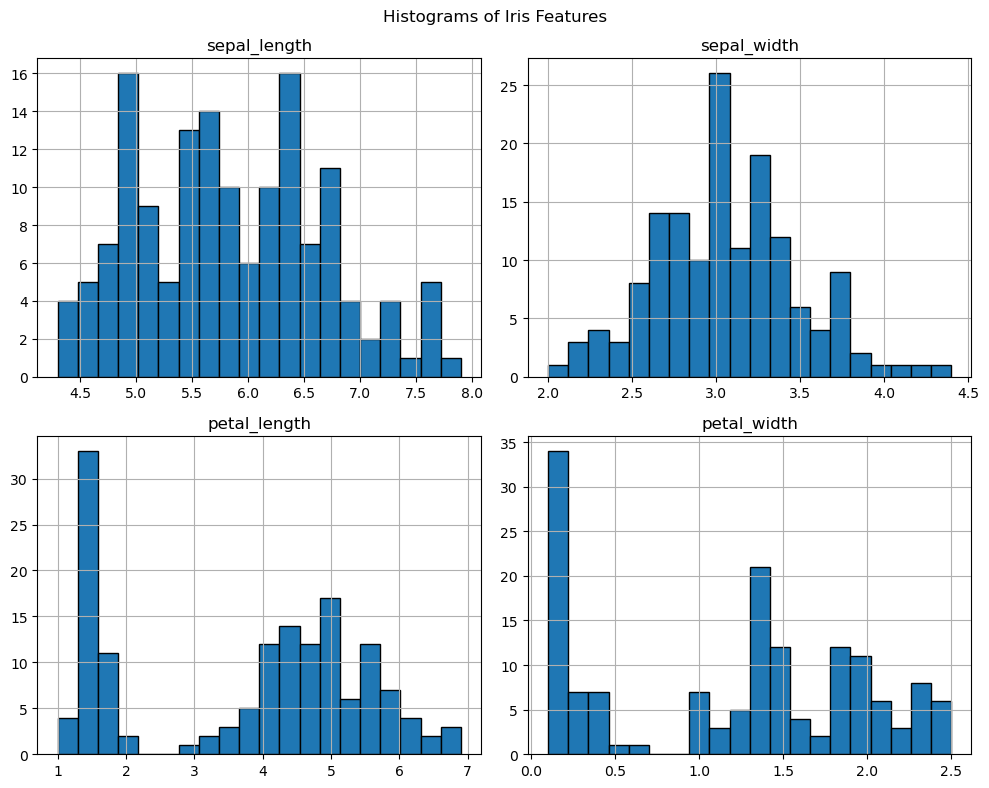

In [10]:
df.hist(figsize=(10, 8), bins=20, edgecolor='black')
plt.suptitle("Histograms of Iris Features")
plt.tight_layout()
plt.show()

<Axes: xlabel='sepal_length', ylabel='Count'>

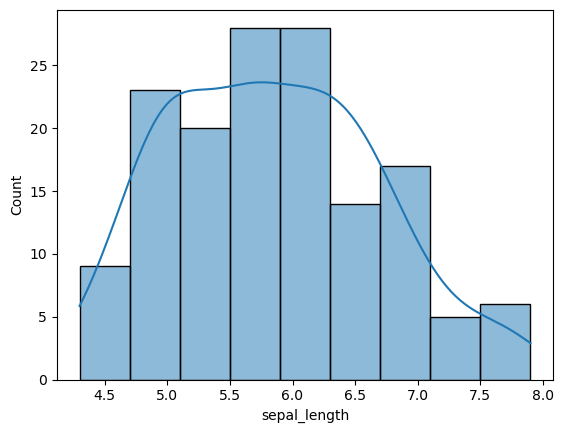

In [12]:
sns.histplot(x = df['sepal_length'], kde=True)

<Axes: xlabel='petal_width', ylabel='Count'>

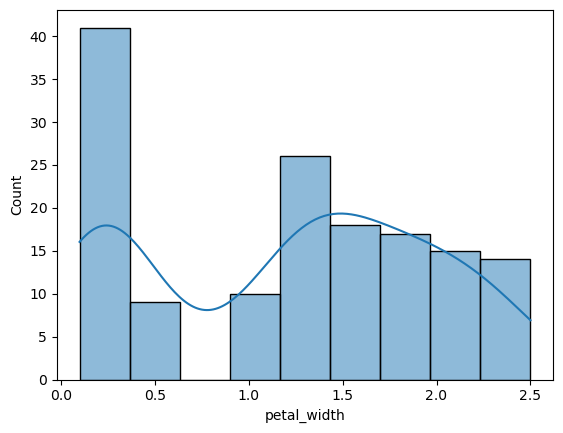

In [14]:
sns.histplot(x = df['petal_width'], kde=True)
#u can do same for others too

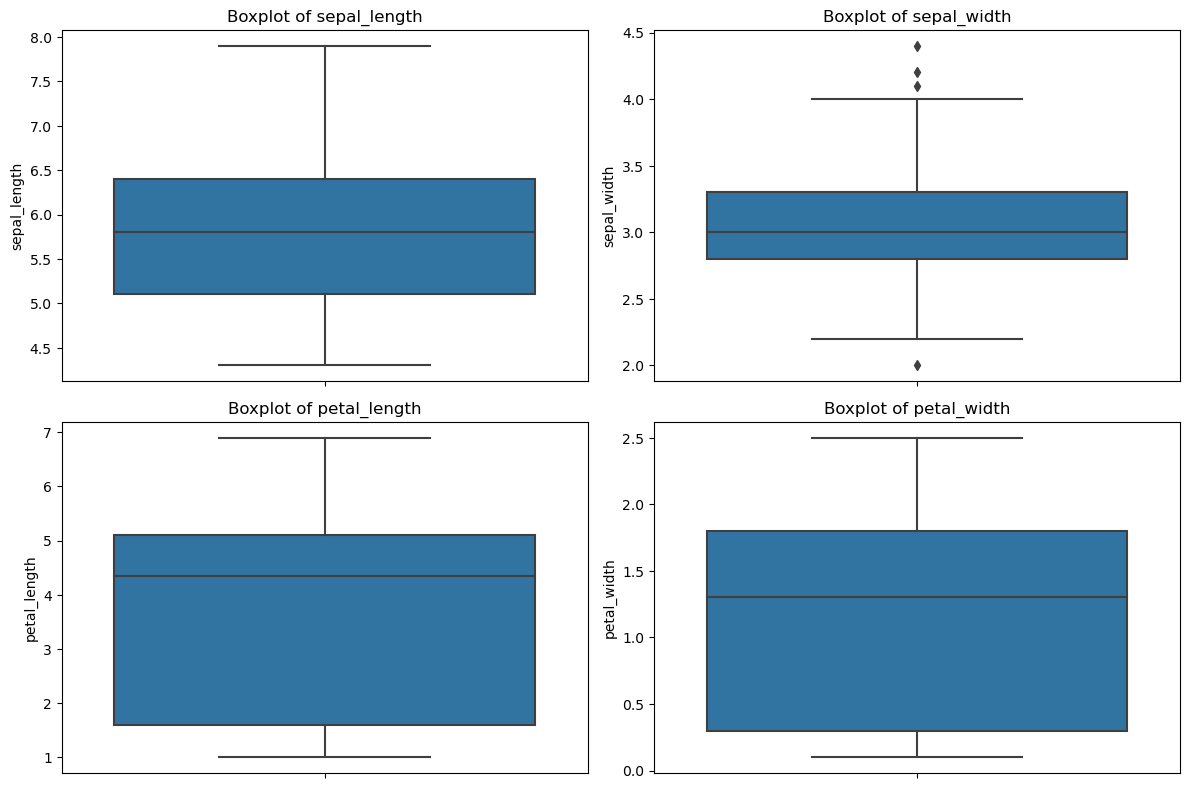

In [15]:
plt.figure(figsize=(12, 8))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=column, data=df)
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()

<Axes: >

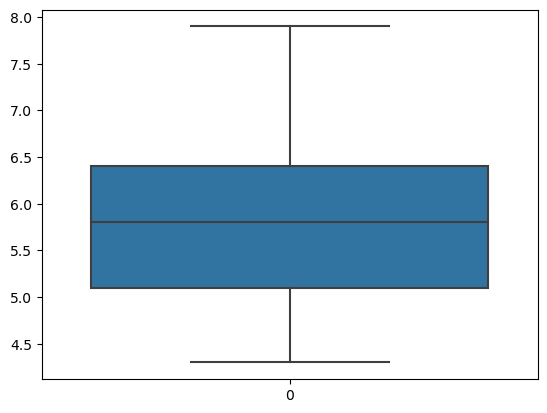

In [17]:
sns.boxplot(df['sepal_length'])

<Axes: >

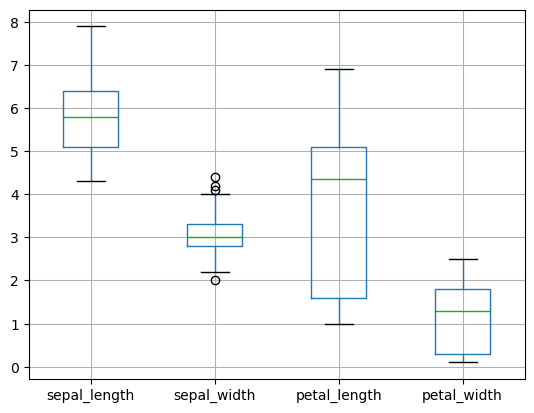

In [19]:
numerical_col = ['sepal_length','sepal_width','petal_length','petal_width']
categorical_col = ['species']
df.boxplot(numerical_col)

<Axes: xlabel='species', ylabel='petal_width'>

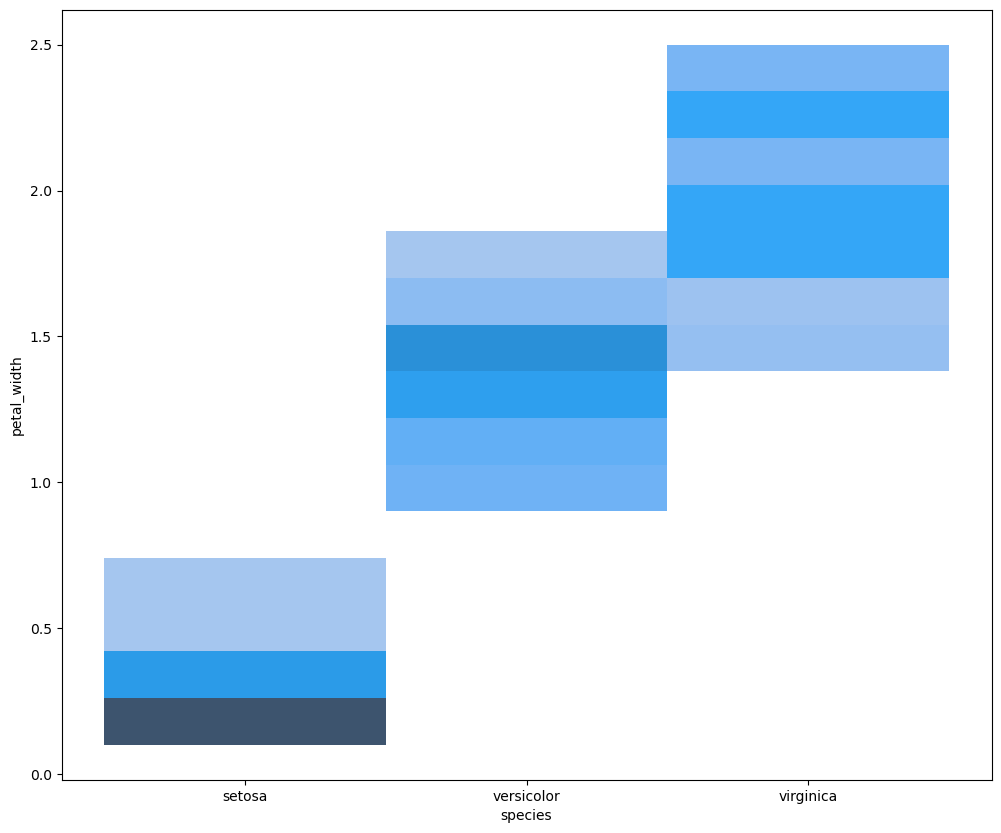

In [20]:
plt.figure(figsize=(12,10))
sns.histplot(data=df, x="species", y="petal_width", bins=15)

In [21]:
#optional #optional---------------------------

print("\nPotential Outliers based on IQR:")
for column in df.columns[:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[column] < Q1 - 1.5 * IQR) | (df[column] > Q3 + 1.5 * IQR)]
    print(f"{column}: {len(outliers)} potential outliers")
    


Potential Outliers based on IQR:
sepal_length: 0 potential outliers
sepal_width: 4 potential outliers
petal_length: 0 potential outliers
petal_width: 0 potential outliers


In [22]:
#optinla dont do this*********Nit vach he karu nakos
for column in df.columns[:-1]:  # Exclude 'species' column
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    print(f"\nFeature: {column}")
    print(f"  Mean: {df[column].mean():.2f}, Median: {df[column].median():.2f}, Std Dev: {df[column].std():.2f}")
    print(f"  Outliers Detected: {'Yes' if not outliers.empty else 'No'}","\n  " f"Outlier Values: {outliers.tolist()}" if not outliers.empty else "")
    print("-" * 40)


Feature: sepal_length
  Mean: 5.84, Median: 5.80, Std Dev: 0.83
  Outliers Detected: No 
----------------------------------------

Feature: sepal_width
  Mean: 3.06, Median: 3.00, Std Dev: 0.44
  Outliers Detected: Yes 
  Outlier Values: [4.4, 4.1, 4.2, 2.0]
----------------------------------------

Feature: petal_length
  Mean: 3.76, Median: 4.35, Std Dev: 1.77
  Outliers Detected: No 
----------------------------------------

Feature: petal_width
  Mean: 1.20, Median: 1.30, Std Dev: 0.76
  Outliers Detected: No 
----------------------------------------
